In [2]:
from environment import CoronagraphEnvironment
import hcipy
from hcipy import *
from matplotlib import pyplot as plt
import numpy as np
from collections import defaultdict
%load_ext autoreload
%autoreload 2

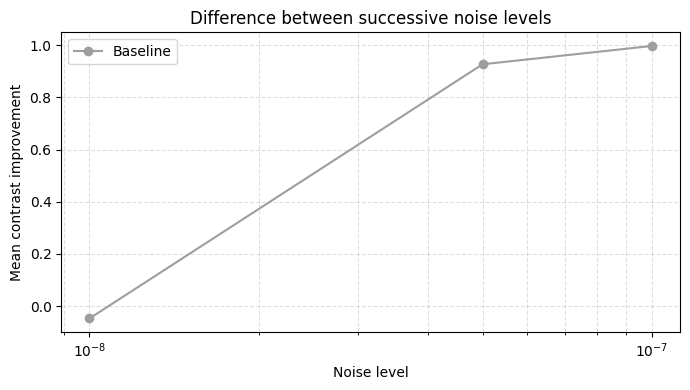

In [32]:
mean_correction_magnitude_model_2 = [0.047146, 0.047148, 0.0471, 0.04747, 0.0630, 0.083611]
mean_correction_magnitude_model_1 = [0.05792, 0.05748, 0.055891, 0.26905, 0.700151, 1.29924]
mean_correction_magnitude_model_baseline = [1.54122, 3.07276, 4.98519, 52.77409, 271.2470, 469.7994]

noise_levels =[1e-8, 5e-8, 1e-7, 2e-7, 3e-7, 4e-7]

# Values pulled from visualize.ipynb

mean_contrast_improvement_model_2 = [-0.030493594431390818, -0.00048174044747391695, 0.002153828439643785, -0.0019348657025474076, 0.0009287809636201109, 0.007696465559483978]
mean_contrast_improvement_model_1 = [-0.012018349511356158, -0.00023147762323895763, 0.00057094368943185, 0.0029678706185609564, 0.02978148460811387, 0.066487938850404]
mean_contrast_improvement_model_baseline = [-0.04738280250103497, 0.9266473239799252, 0.9968232759265826, -108.29521734772742, -191.35380564160985, -114.3206015428562]

# compute successive differences (upper level minus previous level) for each model
delta_baseline = np.diff(np.asarray(mean_correction_magnitude_model_baseline))
delta_model1 = np.diff(np.asarray(mean_correction_magnitude_model_1))
delta_model2 = np.diff(np.asarray(mean_correction_magnitude_model_2))

# plot differences vs the upper noise level of each interval
upper_levels = noise_levels[1:]
plt.figure(figsize=(7, 4))
plt.plot(noise_levels[:3], mean_contrast_improvement_model_baseline[:3], marker='o', color='#9e9e9e', label='Baseline')
# plt.plot(noise_levels, mean_contrast_improvement_model_1, marker='o', color='#1f77b4', label='Model 1')
# plt.plot(noise_levels, mean_contrast_improvement_model_2, marker='o', color='#2ca02c', label='Model 2')
plt.xscale('log')
plt.xlabel('Noise level')
plt.ylabel('Mean contrast improvement')
plt.title('Difference between successive noise levels')
plt.grid(True, which='both', ls='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()


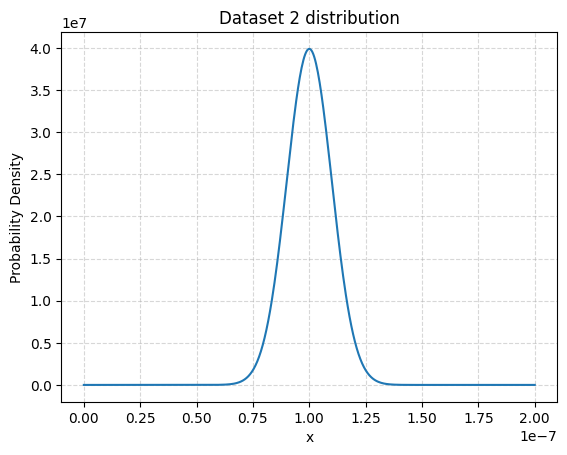

In [17]:
mu, sigma = 1e-7, 1e-8
x = np.linspace(0, 2e-7, 500)
pdf = (1/(np.sqrt(2*np.pi)*sigma)) * np.exp(-0.5*((x - mu)/sigma)**2)


plt.figure()
plt.plot(x, pdf)
plt.xlabel('x')
plt.ylabel('Probability Density')
plt.title('Dataset 2 distribution')
plt.grid(True, ls='--', alpha=0.5)
plt.show()

In [ ]:
e = CoronagraphEnvironment(num_modes=21, pixels=64, oversizing_factor=1, num_airy=5, pixels_per_spacial_res=6, coronagraph_charge=6, num_iterations=1, basis='zernike', num_noise_modes=10000)

initializing coronagraph env. might take a minute.


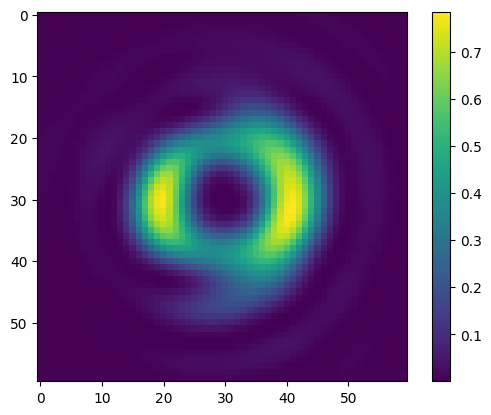

In [104]:
e.deformable_mirror.flatten()
e.noise_gen_mirror.flatten()
e.set_random_dm(noise=1e-7)
img = e.get_camera_image(delta_t=1e-3, noise_enabled=False, coronagraph_enabled=True)
plt.imshow(img)
plt.colorbar()


initializing coronagraph env. might take a minute.


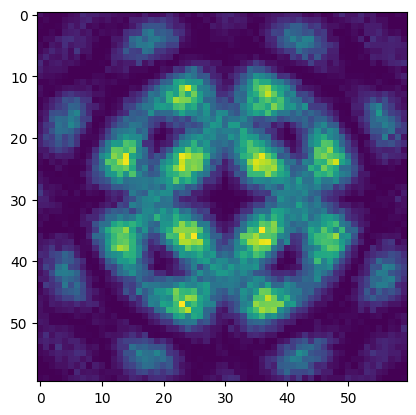

In [55]:
e = CoronagraphEnvironment(num_modes=21, pixels=64, oversizing_factor=1, num_airy=5, pixels_per_spacial_res=6, coronagraph_charge=6, num_iterations=1, basis='zernike')
e.set_random_dm(noise=1e-20)
img = e.get_camera_image(delta_t=1e3)
plt.imshow(img)


initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.


C:\Users\alexe\AppData\Local\Temp\ipykernel_51252\500279336.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


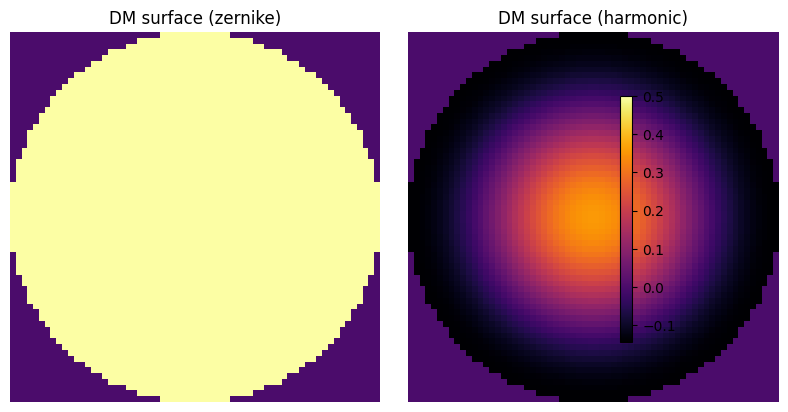

<Figure size 640x480 with 0 Axes>

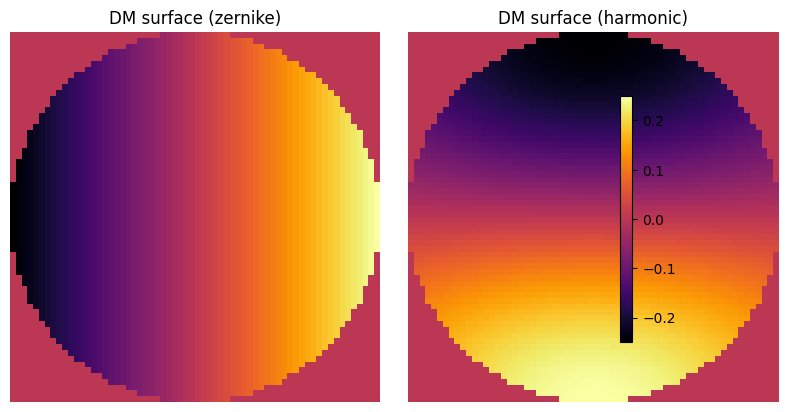

<Figure size 640x480 with 0 Axes>

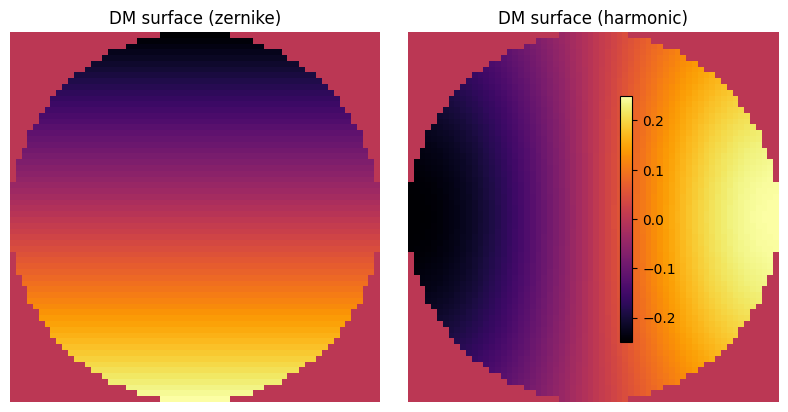

<Figure size 640x480 with 0 Axes>

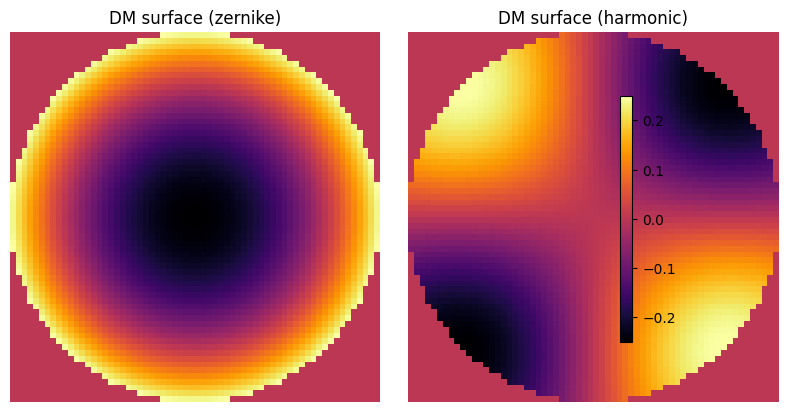

<Figure size 640x480 with 0 Axes>

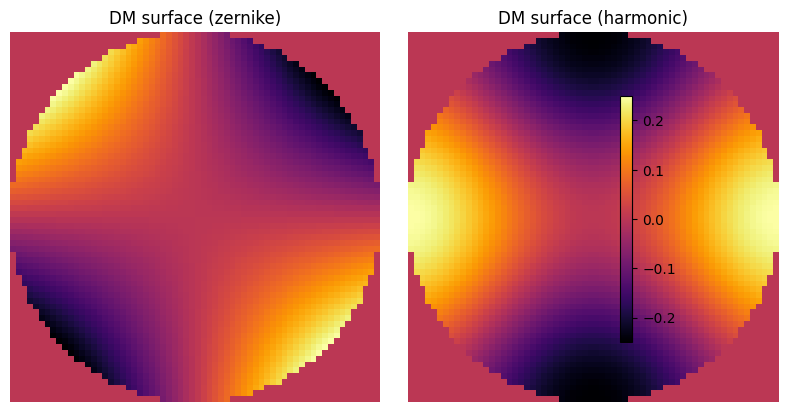

<Figure size 640x480 with 0 Axes>

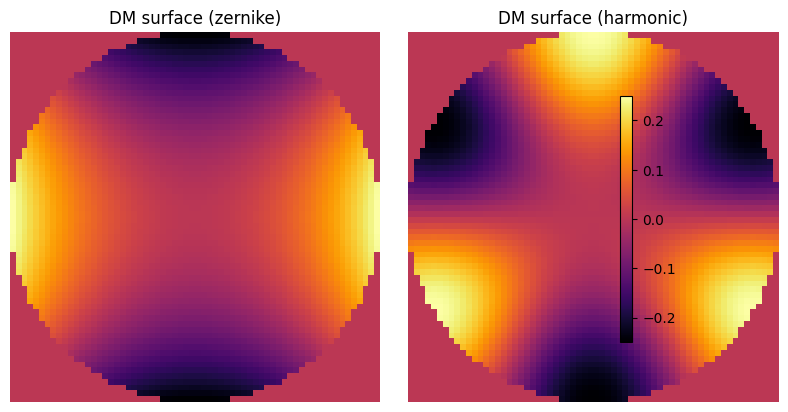

<Figure size 640x480 with 0 Axes>

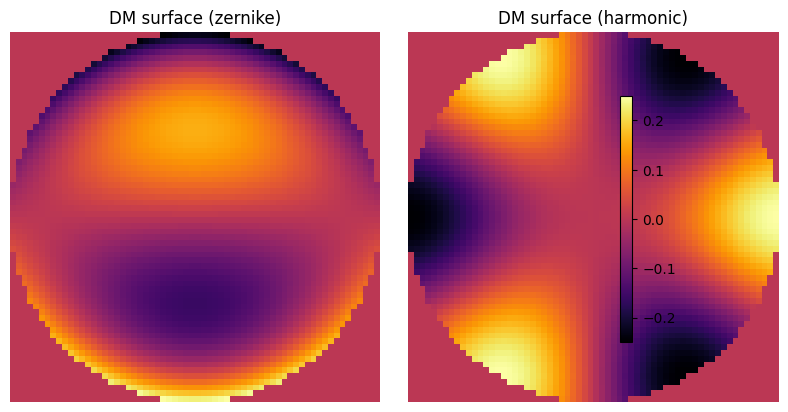

<Figure size 640x480 with 0 Axes>

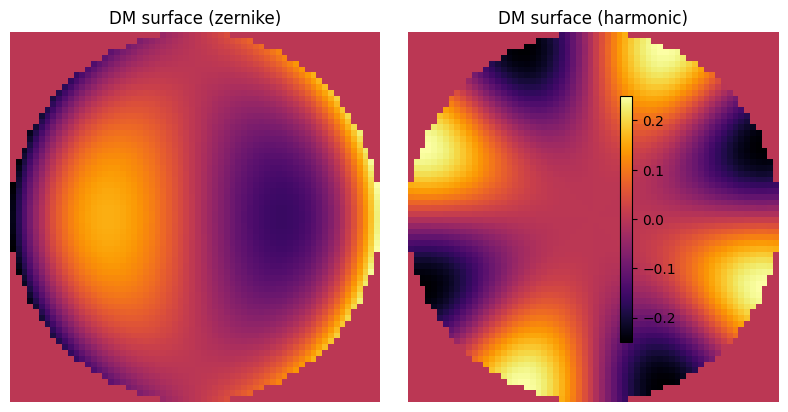

<Figure size 640x480 with 0 Axes>

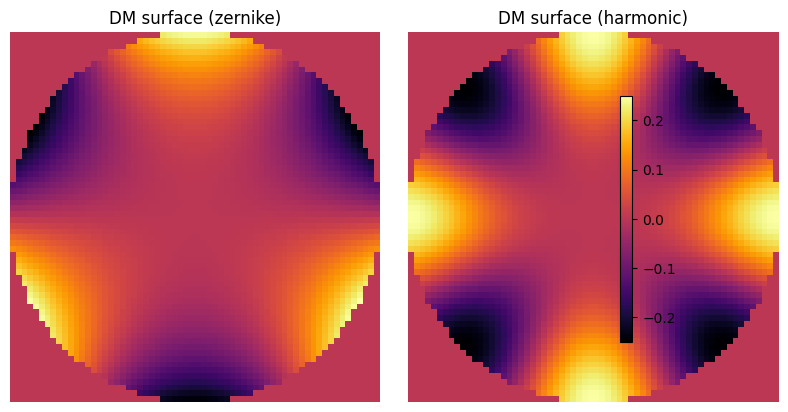

<Figure size 640x480 with 0 Axes>

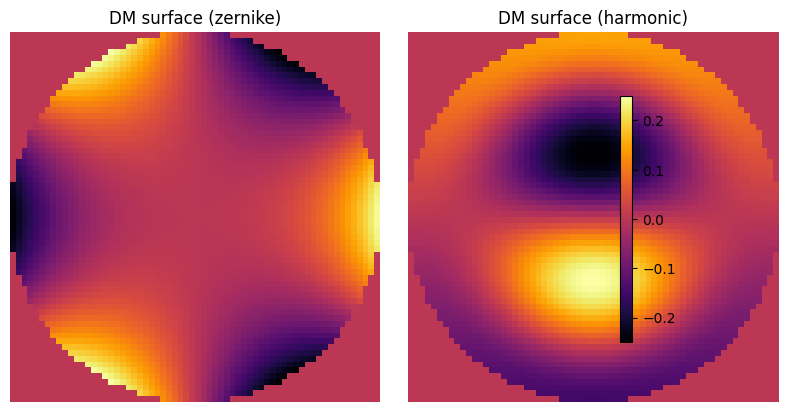

<Figure size 640x480 with 0 Axes>

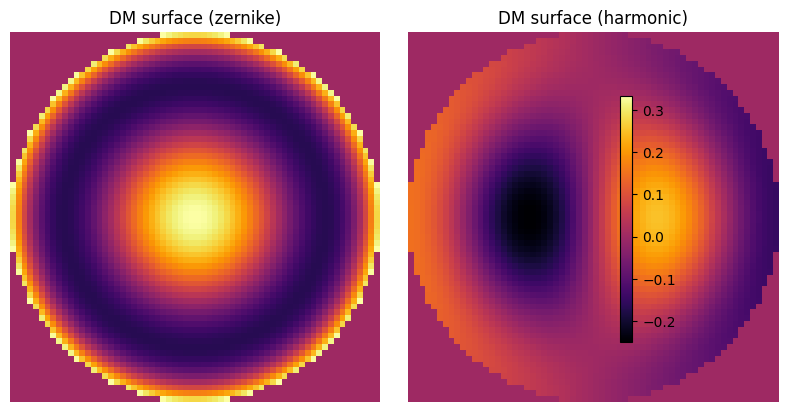

<Figure size 640x480 with 0 Axes>

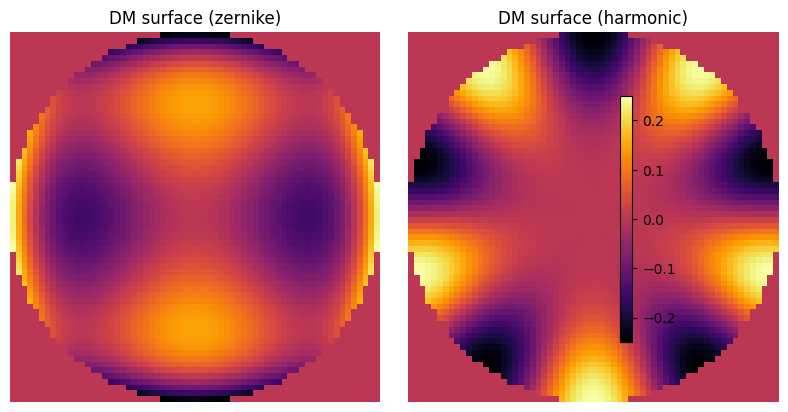

<Figure size 640x480 with 0 Axes>

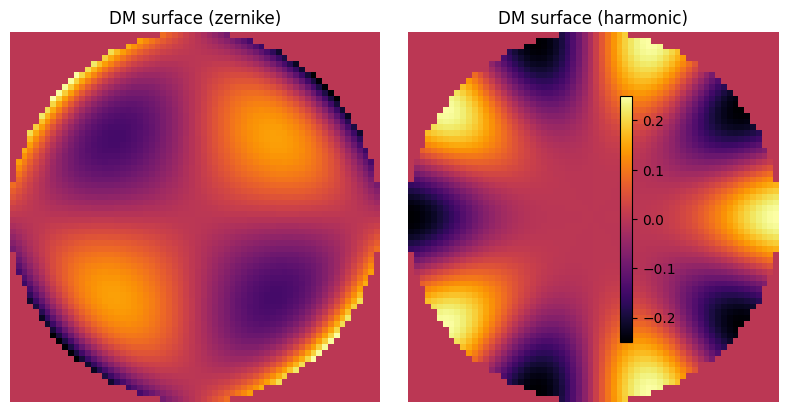

<Figure size 640x480 with 0 Axes>

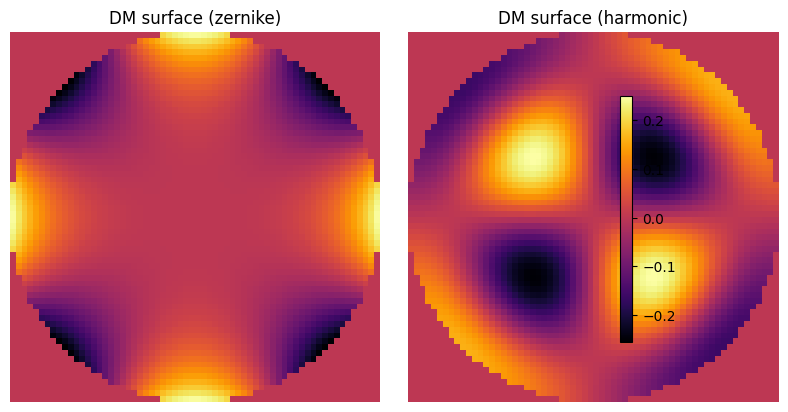

<Figure size 640x480 with 0 Axes>

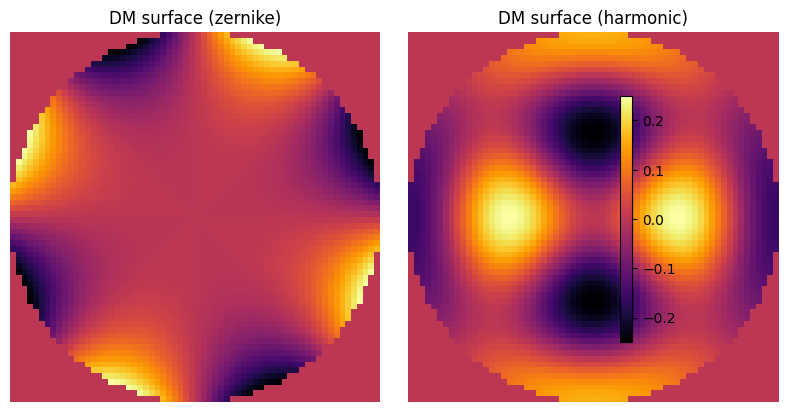

<Figure size 640x480 with 0 Axes>

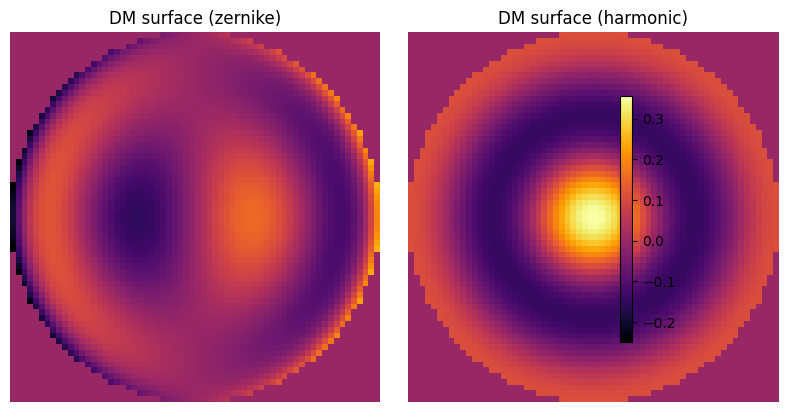

<Figure size 640x480 with 0 Axes>

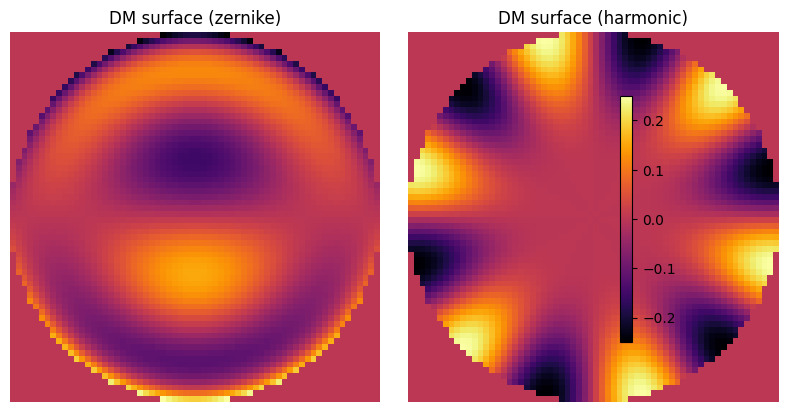

<Figure size 640x480 with 0 Axes>

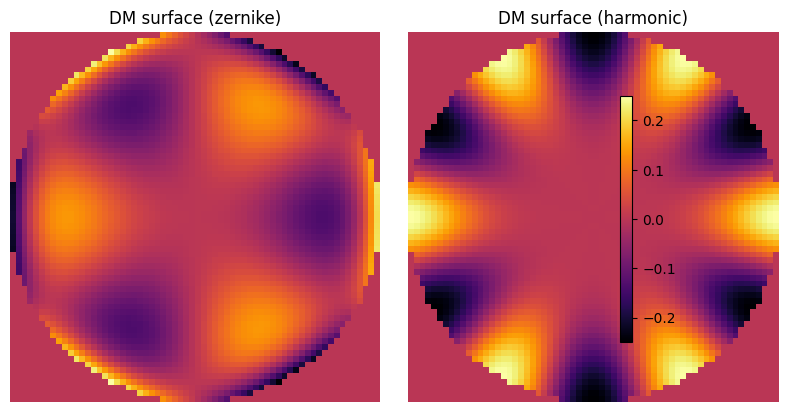

<Figure size 640x480 with 0 Axes>

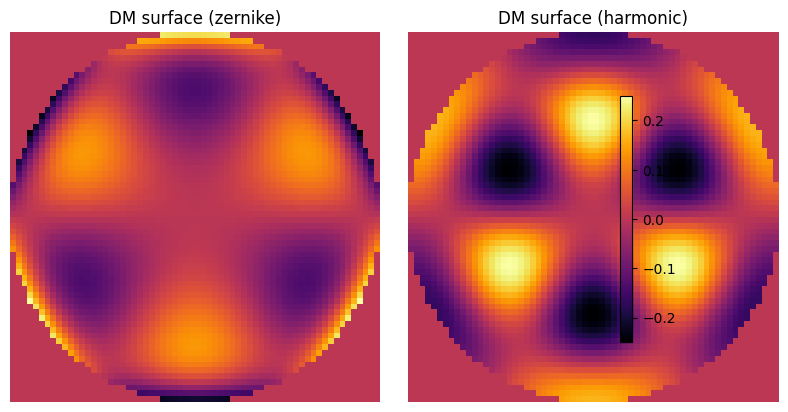

<Figure size 640x480 with 0 Axes>

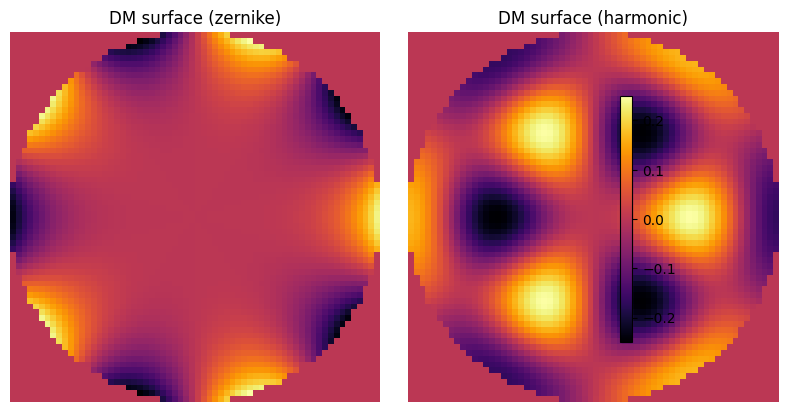

<Figure size 640x480 with 0 Axes>

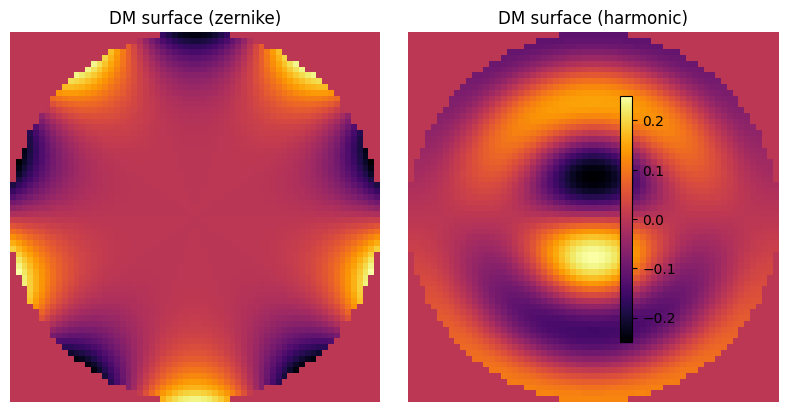

<Figure size 640x480 with 0 Axes>

In [20]:
e = CoronagraphEnvironment(num_modes=21, pixels=64, oversizing_factor=1, num_airy=5, pixels_per_spacial_res=2, coronagraph_charge=6, num_iterations=1, basis='zernike')
e2 = CoronagraphEnvironment(num_modes=21, pixels=64, oversizing_factor=1, num_airy=5, pixels_per_spacial_res=2, coronagraph_charge=6, num_iterations=1, basis='harmonic')


for i in range(21):
    e.deformable_mirror.flatten()
    e2.deformable_mirror.flatten()

    action = np.zeros(shape=(21,))
    action[i] = 0.5  # Apply a small poke on mode i
    e.set_dm(action=action)
    e2.set_dm(action=action)
    s1 = e.deformable_mirror.surface.reshape((64, 64))
    s2 = e2.deformable_mirror.surface.reshape((64, 64))
    vmin = min(s1.min(), s2.min())
    vmax = max(s1.max(), s2.max())

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    im0 = axes[0].imshow(s1, cmap='inferno', vmin=vmin, vmax=vmax)
    axes[0].set_title('DM surface (zernike)')
    axes[0].axis('off')
    im1 = axes[1].imshow(s2, cmap='inferno', vmin=vmin, vmax=vmax)
    axes[1].set_title('DM surface (harmonic)')
    axes[1].axis('off')
    fig.colorbar(im1, ax=axes.ravel().tolist(), shrink=0.8)
    plt.tight_layout()

    # ensure the following imshow draws on a new figure
    plt.figure()
    plt.show()

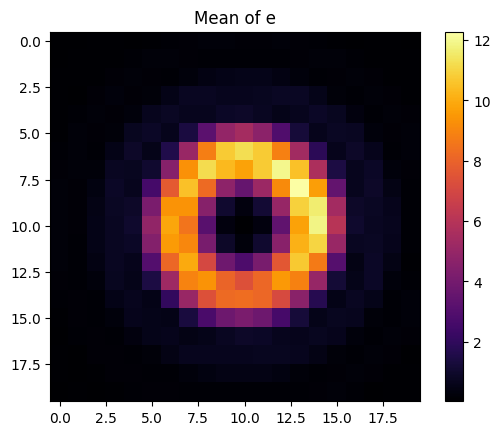

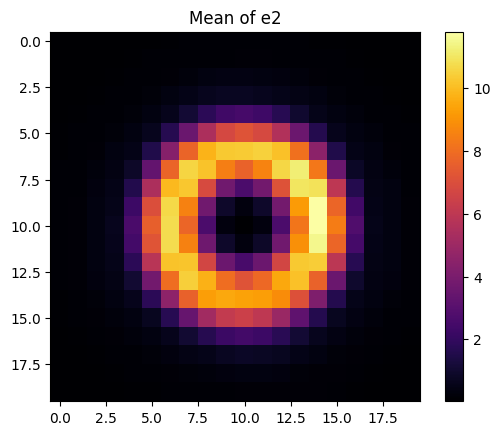

Mean image difference (L2 norm): 19.4650646667855
Mean of e mean pixel value: 1.8868140484967553
Mean of e2 mean pixel value: 2.1604895109980253
Max pixel value of e mean image: 12.280216845550628
Max pixel value of e2 mean image: 11.802174854291124


In [22]:
# Compute mean images for e and e2 over 1000 samples using matched DM actuators
N = 100

def _as_img(a):
    a = np.asarray(a)
    if a.ndim == 2:
        return a
    s = int(np.sqrt(a.size))
    return a.reshape((s, s)) if s * s == a.size else a

sum_e = None
sum_e2 = None

for _ in range(N):
    e.set_random_dm(noise=1e-7)
    # dm = e.deformable_mirror.actuators.copy()
    e2.set_random_dm(noise=1e-7)

    img_e = _as_img(e.get_camera_image(delta_t=1e-3, noise_enabled=False))
    img_e2 = _as_img(e2.get_camera_image(delta_t=1e-3, noise_enabled=False))

    if sum_e is None:
        sum_e = np.zeros_like(img_e, dtype=float)
        sum_e2 = np.zeros_like(img_e2, dtype=float)

    sum_e += img_e
    sum_e2 += img_e2

mean_e = sum_e / N
mean_e2 = sum_e2 / N

plt.imshow(mean_e, cmap='inferno')
plt.title('Mean of e')
plt.colorbar()
plt.show()

plt.imshow(mean_e2, cmap='inferno')
plt.title('Mean of e2')
plt.colorbar()
plt.show()

print("Mean image difference (L2 norm):", np.linalg.norm(mean_e - mean_e2))
print("Mean of e mean pixel value:", np.mean(mean_e))
print("Mean of e2 mean pixel value:", np.mean(mean_e2))
print("Max pixel value of e mean image:", np.max(mean_e))
print("Max pixel value of e2 mean image:", np.max(mean_e2))

initializing coronagraph env. might take a minute.


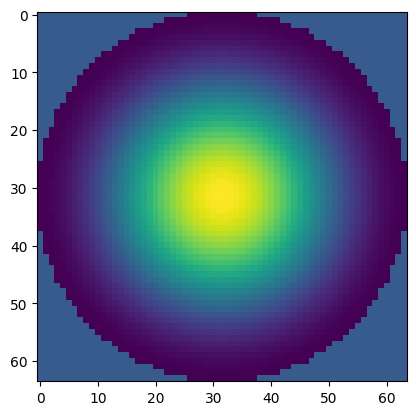

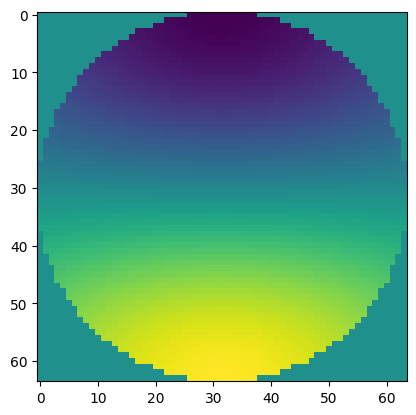

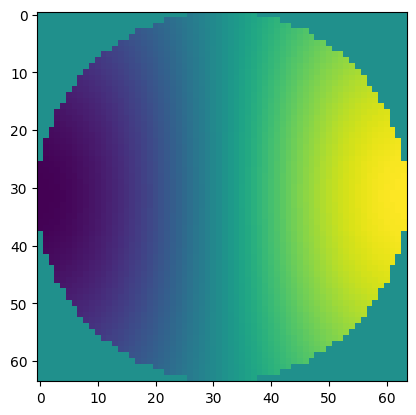

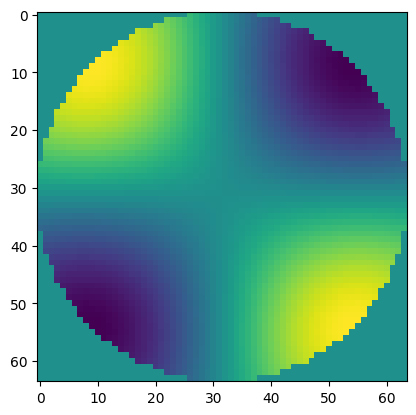

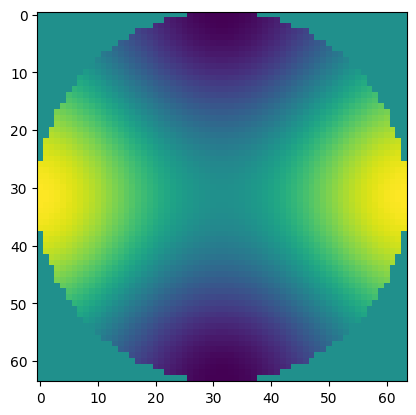

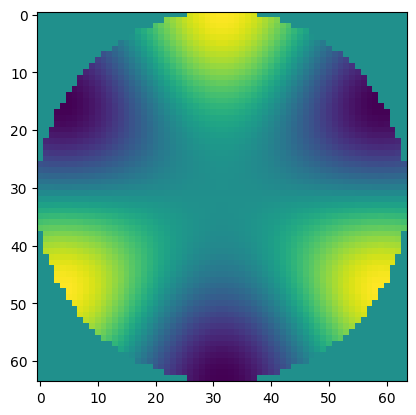

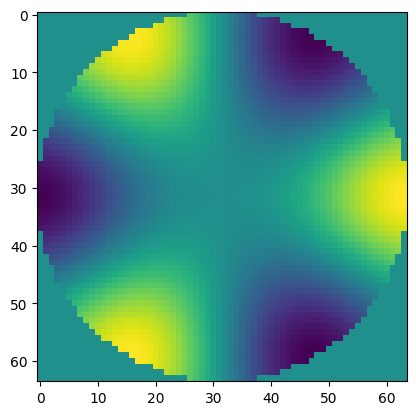

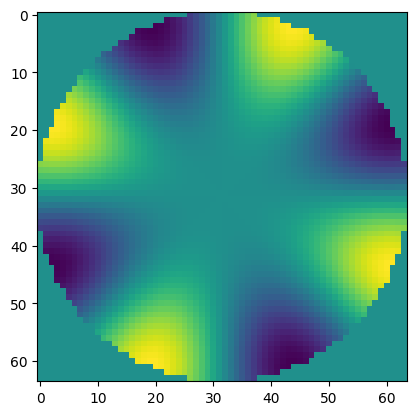

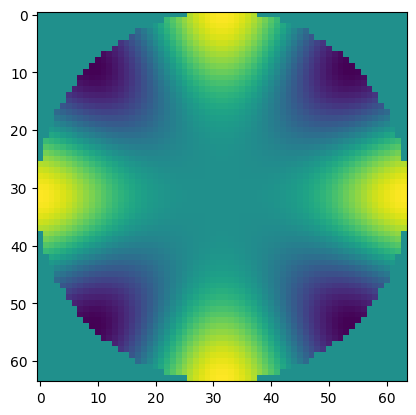

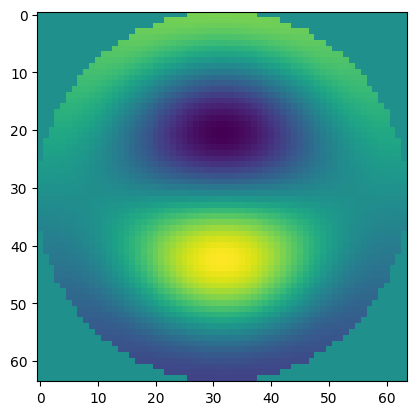

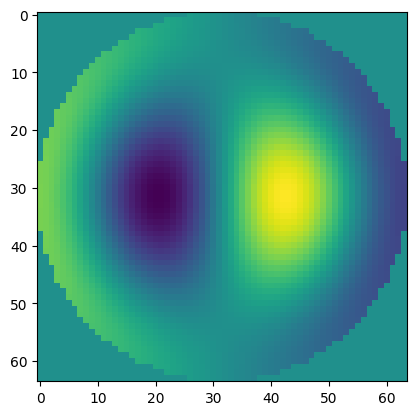

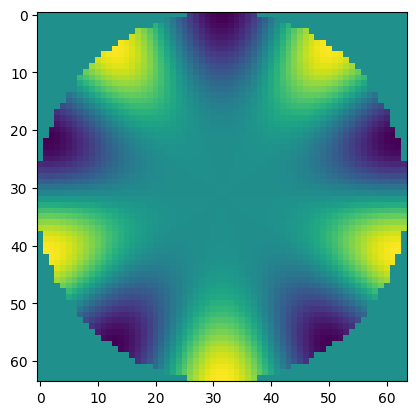

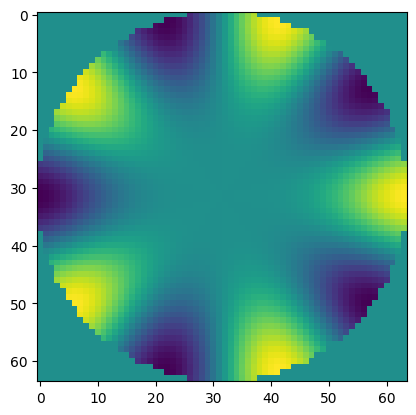

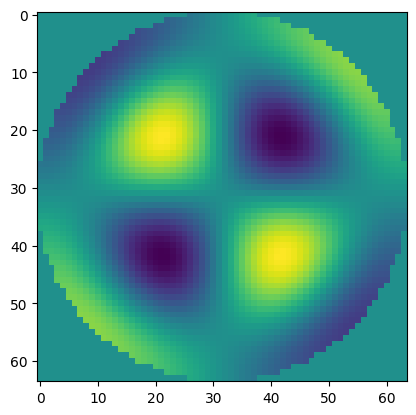

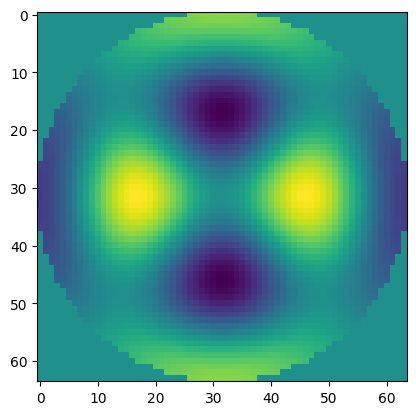

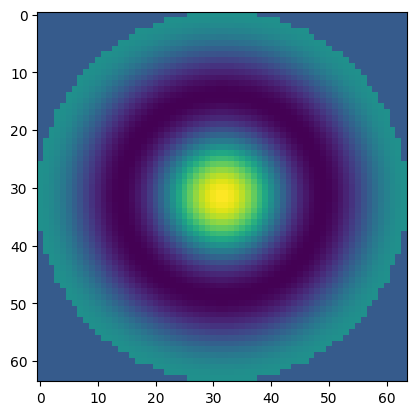

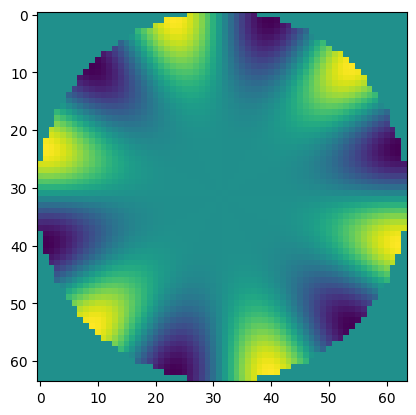

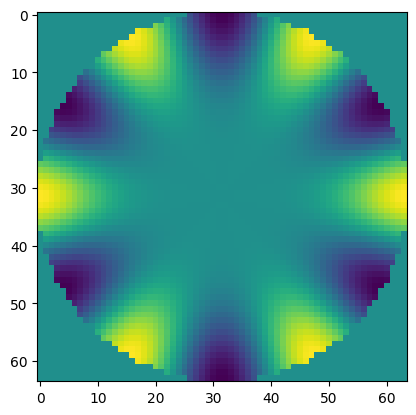

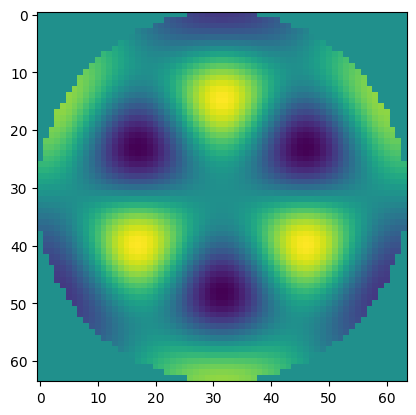

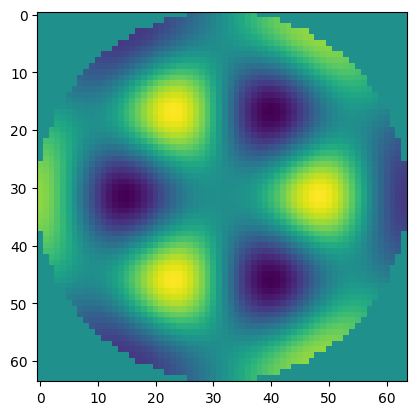

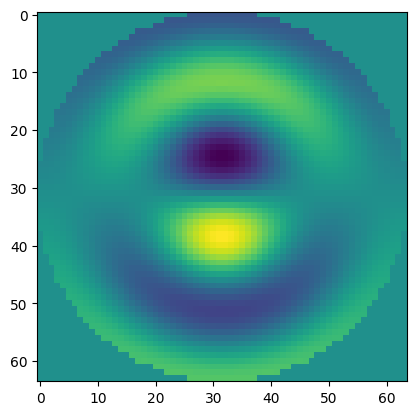

In [5]:
e = CoronagraphEnvironment(num_modes=21, pixels=64, oversizing_factor=1, num_airy=5, pixels_per_spacial_res=2, coronagraph_charge=6, num_iterations=1, basis='harmonic')

for i in range(21):
    e.deformable_mirror.flatten()

    action = np.zeros(shape=(21,))
    action[i] = 0.5  # Apply a small poke on mode i
    e.set_dm(action=action)
    plt.imshow(e.deformable_mirror.surface.reshape((64,64)))
    plt.show()

In [ ]:


e.set_random_dm(noise=1e-7)

def take_random_action(mag):
    action = np.random.uniform(-mag, mag, size=(100,))
    e.step(action=action)


contrasts = defaultdict(list)

for mag in range(int(1e-3), int(1e10), 1):
    print(f"mag = {mag}")
    for _ in range(100):
        e.set_random_dm(noise=1e-7)
        take_random_action(mag)

        contrast = e._get_obs()['strehl']
        contrasts[mag].append(contrast)
        

initializing coronagraph env. might take a minute.
mag = 0
mag = 0
mag = 1
mag = 1
mag = 2
mag = 2
mag = 3
mag = 3


KeyboardInterrupt: 

initializing coronagraph env. might take a minute.


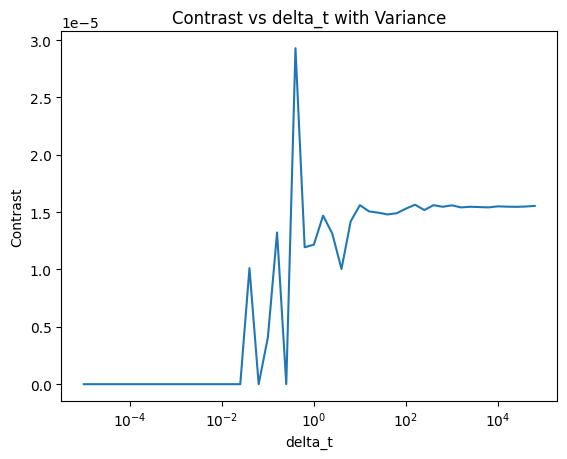

In [2]:
e = CoronagraphEnvironment(num_modes=100, pixels=50, oversizing_factor=(16 / 15), num_airy=5, coronagraph_charge=6)

delta_ts = [10**(power/5) for power in range(-25, 25)]
contrasts = [[] for _ in delta_ts]
repetitions = 1

for index, dt in enumerate(delta_ts):
    for _ in range(repetitions):
        e.deformable_mirror.flatten
        cont = e.get_contrast(delta_t=dt)
        contrasts[index].append(cont)

means = [np.mean(c) for c in contrasts]
variances = [np.var(c) for c in contrasts]

plt.plot(delta_ts, means)
plt.xscale('log')
plt.xlabel('delta_t')
plt.ylabel('Contrast')
plt.title('Contrast vs delta_t with Variance')
plt.show()



In [29]:
e = CoronagraphEnvironment(num_modes=1, pixels=2500, oversizing_factor=1, num_airy=5, coronagraph_charge=6)


initializing coronagraph env. might take a minute.


AssertionError: get_contrast images different shapes.

In [2]:
resolutions = [res for res in range(500, 2000, 500)]
contrasts = []
repetitions = 10

for res in resolutions:
    e = CoronagraphEnvironment(num_modes=1, pixels=res, oversizing_factor=1, num_airy=5, coronagraph_charge=6)
    contrasts.append(
            (
                e.get_contrast(delta_t=1e10)
            )
        )

initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.


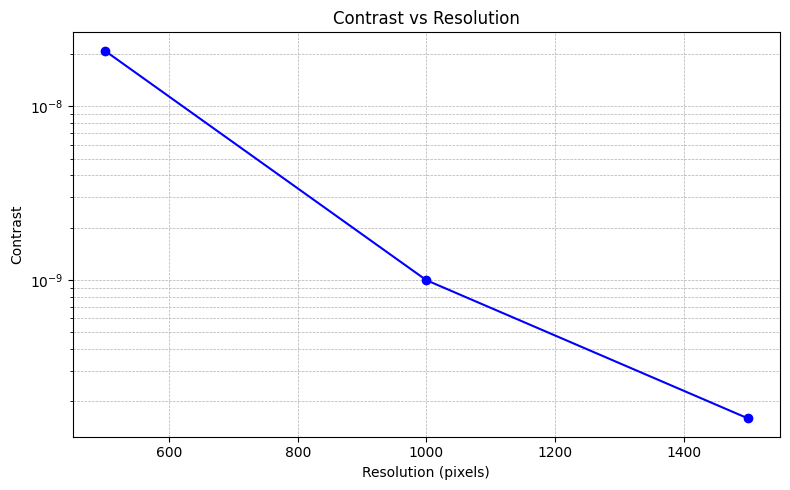

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(resolutions, contrasts, marker='o', linestyle='-', color='b')
plt.xlabel('Resolution (pixels)')
plt.ylabel('Contrast')
plt.title('Contrast vs Resolution')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.yscale('log')
plt.tight_layout()
plt.show()

In [36]:
airies = [airy for airy in range(5, 10)]
contrasts = []
repetitions = 10

for airy in airies:
    e = CoronagraphEnvironment(num_modes=1, pixels=500, oversizing_factor=1, num_airy=airy, coronagraph_charge=6)
    contrasts.append(
            (
                e.get_contrast(delta_t=1e10)
            )
        )


initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.


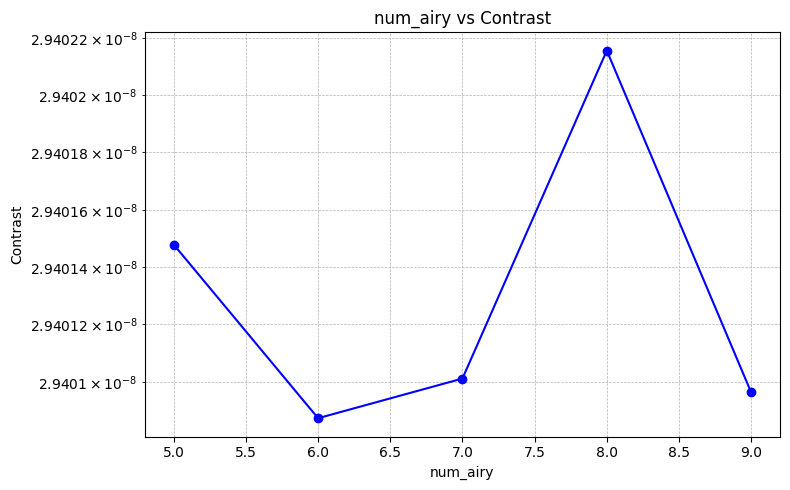

In [37]:
plt.figure(figsize=(8, 5))
plt.plot(airies, contrasts, marker='o', linestyle='-', color='b')
plt.xlabel('Resolution (pixels)')
plt.ylabel('Contrast')
plt.title('Contrast vs Resolution')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.yscale('log')
plt.tight_layout()
plt.xlabel('num_airy')
plt.title('num_airy vs Contrast')
plt.show()

In [17]:
oversizing_factors = np.linspace(1, 4, 20)
contrasts = []
repetitions = 10

for factor in oversizing_factors:
    e = CoronagraphEnvironment(num_modes=1, pixels=500, oversizing_factor=factor, num_airy=7, coronagraph_charge=6)
    contrasts.append(e.get_contrast(delta_t=1e15))

initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.
initializing coronagraph env. m

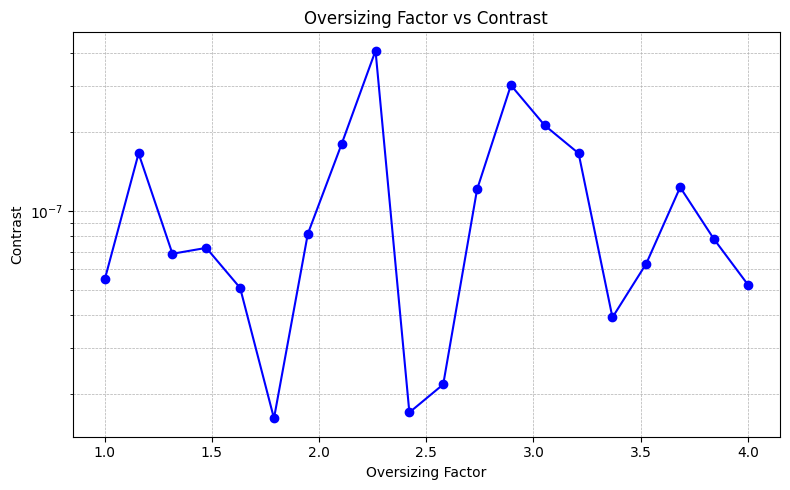

In [19]:
plt.figure(figsize=(8, 5))
plt.ylabel('Contrast')
plt.plot(oversizing_factors, contrasts, marker='o', linestyle='-', color='b')
plt.xlabel('Oversizing Factor')
plt.title('Oversizing Factor vs Contrast')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.yscale('log')
plt.tight_layout()
plt.show()

initializing coronagraph env. might take a minute.
4.951037935865259e-07


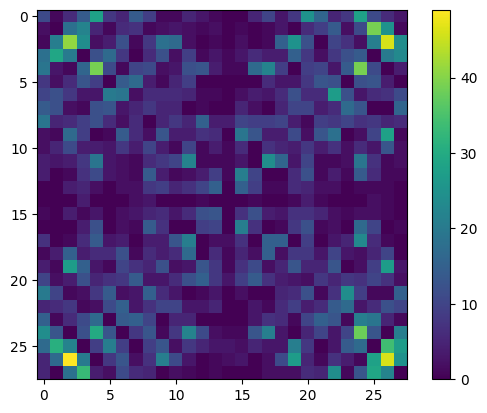

In [9]:
e = CoronagraphEnvironment(num_modes=50, pixels=250, oversizing_factor=1, num_airy=7, coronagraph_charge=6, pixels_per_spacial_res=2)
plt.imshow(e.get_camera_image(delta_t=1e3, coronagraph_enabled=True, crop=False))
plt.colorbar()
print(e.get_contrast(delta_t=1e10))

In [54]:
e = CoronagraphEnvironment(num_modes=200, pixels=64, oversizing_factor=1, num_airy=7, coronagraph_charge=6, pixels_per_spacial_res=6)


initializing coronagraph env. might take a minute.


[-3.19514592e-07  1.95344899e-07  6.78872560e-08  3.95815001e-07
 -1.56305212e-07  1.65273612e-07  2.41164039e-07  1.72329560e-07
  1.46829232e-07 -4.20043588e-08  5.34375662e-08  1.32133417e-07
  1.24570468e-07  1.70187404e-07  1.59881969e-07 -1.15435929e-07
 -1.38686329e-07 -3.45519306e-08  6.97585138e-09 -1.09424181e-07
  1.31812603e-07  1.52199444e-07  1.48302234e-07 -8.14737697e-09
  1.67117013e-07  3.14330411e-08  1.02542005e-07 -1.42649458e-08
  1.67873983e-07 -2.71510279e-08  1.56264453e-07 -9.33197807e-08
 -2.72628685e-09  1.94428929e-08  7.75135533e-08  1.83704076e-10
 -1.00174431e-07 -8.75036814e-08 -8.39460611e-08  6.92627527e-08
  1.89289688e-08 -8.69807237e-09  1.15265805e-07 -1.11161960e-07
  7.52354064e-09  6.22339326e-08 -5.55027248e-09  2.39437691e-08
 -3.02607814e-08 -7.33458040e-08 -3.28677824e-09 -7.46393561e-08
  9.44834255e-08 -1.61745966e-08  5.67810121e-08  6.52528784e-08
  1.40349268e-08  6.27049684e-08 -5.91185967e-08 -6.01471011e-08
  1.33457119e-08 -5.60565

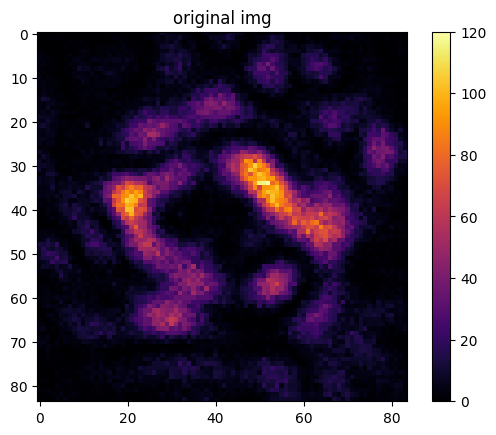

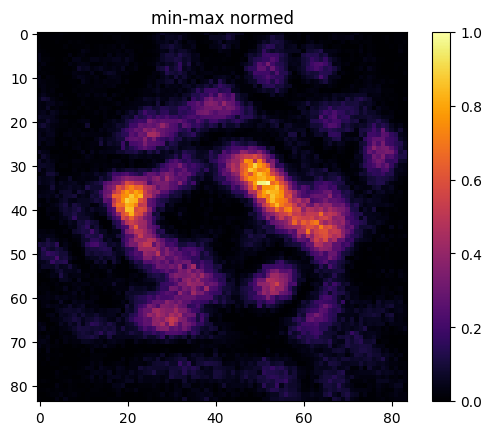

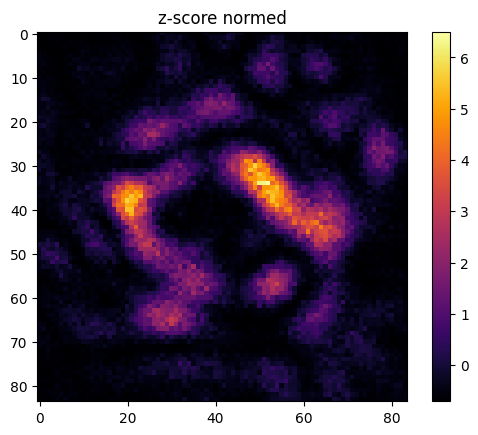

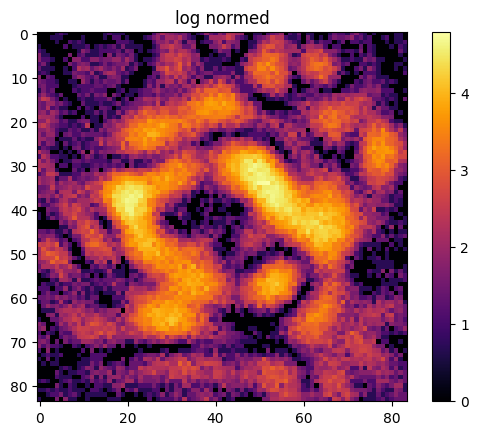

In [60]:
# e.set_random_dm(noise=1e-6)
# original = e.deformable_mirror.actuators.copy()
print(original)
img = e.get_camera_image(delta_t=1e-3, coronagraph_enabled=True, crop=False)
img_max, img_min = np.max(img), np.min(img)
img_mean, img_std = np.mean(img), np.std(img)

img_mm = (img - img_min) / (img_max - img_min)
img_zs = (img - img_mean) / img_std
img_lg = np.log(img + 1) 

plt.imshow(img, cmap='inferno')
plt.title('original img')
plt.colorbar()
plt.show()

plt.imshow(img_mm, cmap='inferno')
plt.title('min-max normed')
plt.colorbar()
plt.show()

plt.imshow(img_zs, cmap='inferno')
plt.title('z-score normed')
plt.colorbar()
plt.show()

plt.imshow(img_lg, cmap='inferno')
plt.title('log normed')
plt.colorbar()
plt.show()

In [71]:
e = CoronagraphEnvironment(num_modes=200, pixels=64, oversizing_factor=1, num_airy=7, coronagraph_charge=6, pixels_per_spacial_res=2)

initializing coronagraph env. might take a minute.


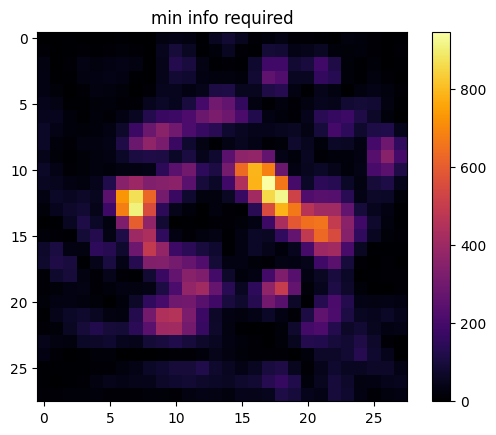

In [72]:
e.deformable_mirror.actuators = original
img = e.get_camera_image(delta_t=1e-3, coronagraph_enabled=True, crop=False)
img_max, img_min = np.max(img), np.min(img)
img_mean, img_std = np.mean(img), np.std(img)

img_mm = (img - img_min) / (img_max - img_min)
img_zs = (img - img_mean) / img_std
img_lg = np.log(img + 1) 

plt.imshow(img, cmap='inferno')
plt.title('min info required')
plt.colorbar()
plt.show()


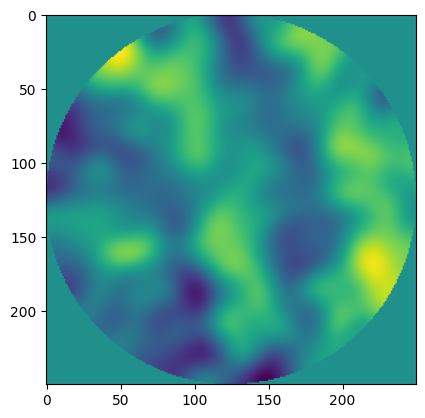

In [38]:
e.set_random_dm(noise=0.01)
plt.imshow(np.reshape(e.deformable_mirror.surface, (250, 250)))

In [2]:
num_modes_options = [5, 10, 25, 50, 100, 200, 300, 500]
noises = np.linspace(1e-7, 1e-2, 50)
all_graphs = []
all_variances = []
repetitions = 100

for num_modes in num_modes_options:
    e = CoronagraphEnvironment(num_modes=num_modes, pixels=20, oversizing_factor=1, num_airy=7, coronagraph_charge=6, pixels_per_spacial_res=2)
    dm_magnitudes = []
    variances = []
    for noise in noises:
        temp = []
        for _ in range(repetitions):
            e.set_random_dm(noise=noise)
            magnitude = np.linalg.norm(e.deformable_mirror.actuators)
            temp.append(magnitude)
        variances.append(np.var(temp))
        dm_magnitudes.append(np.mean(temp))
    all_variances.append(variances)
    all_graphs.append(dm_magnitudes)


initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.


In [55]:
print(all_graphs)

[[np.float64(9.50168802662912e-13), np.float64(2.016460188841297e-09), np.float64(3.936460058578705e-09), np.float64(5.837199742880498e-09), np.float64(7.87727435691887e-09), np.float64(1.0202873149832781e-08), np.float64(1.1724311381251106e-08), np.float64(1.392529271242257e-08), np.float64(1.5931135570599926e-08), np.float64(1.8161521171675867e-08), np.float64(1.9289393565008845e-08), np.float64(2.1591613636368685e-08), np.float64(2.334328950826119e-08), np.float64(2.6058705013603604e-08), np.float64(2.7626883199398946e-08), np.float64(2.9770489262368146e-08), np.float64(3.120997219417409e-08), np.float64(3.378148457126239e-08), np.float64(3.6470618007350936e-08), np.float64(3.76368915671052e-08), np.float64(3.988554813384646e-08), np.float64(4.2298487657069244e-08), np.float64(4.380726776025806e-08), np.float64(4.5562117558996636e-08), np.float64(4.670069612736275e-08), np.float64(4.8731949358627373e-08), np.float64(5.2393395133180587e-08), np.float64(5.459839345383845e-08), np.floa

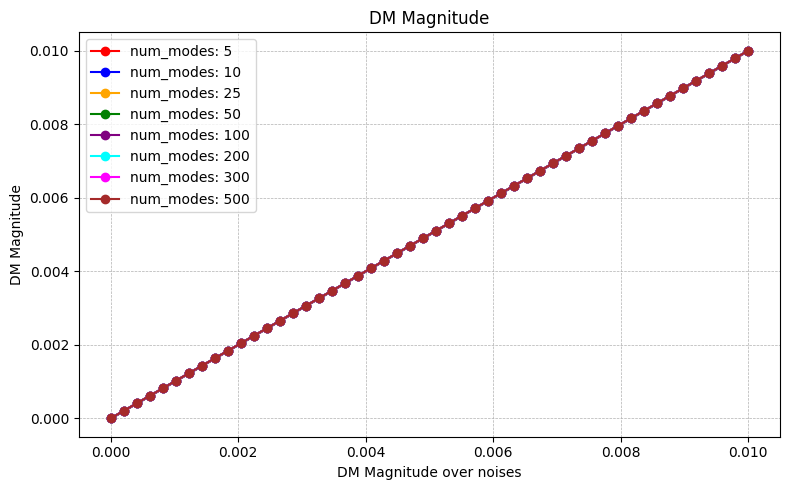

In [3]:
from itertools import cycle



colors = ['r', 'b', 'orange', 'green', 'purple', 'cyan'][:len(num_modes_options)]
# Extend colors list if needed
if len(colors) < len(num_modes_options):
    extra_colors = ['magenta', 'brown', 'olive', 'pink', 'gray', 'teal', 'navy', 'gold', 'lime', 'coral', 'indigo']
    colors = (colors + extra_colors)[:len(num_modes_options)]

plt.figure(figsize=(8, 5))
plt.ylabel('DM Magnitude')
for index, num_modes in enumerate(num_modes_options):
    plt.plot(noises, all_graphs[index], marker='o', linestyle='-', color=colors[index], label=f"num_modes: {num_modes}")
    plt.fill_between(noises, 
                     np.array(all_graphs[index]) - np.sqrt(all_variances[index]), 
                     np.array(all_graphs[index]) + np.sqrt(all_variances[index]), 
                     color=colors[index], alpha=0.2)
    
    
plt.xlabel('DM Magnitude over noises')
plt.title('DM Magnitude')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [2]:
e = CoronagraphEnvironment(num_modes=100, pixels=250, oversizing_factor=1, num_airy=7, coronagraph_charge=6, pixels_per_spacial_res=4)

initializing coronagraph env. might take a minute.


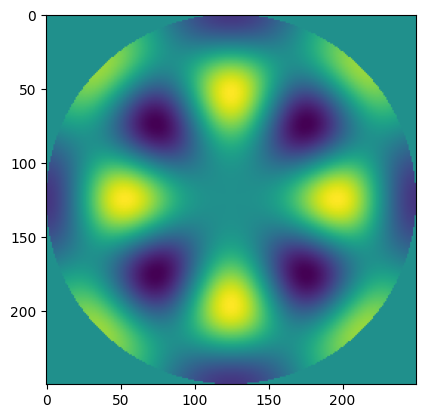

In [9]:
action = [0 for _ in range(100)]
action[25] = 0.1
e.deformable_mirror.flatten()
e.set_dm(action=action)
plt.imshow(np.reshape(e.deformable_mirror.surface, (250, 250)))


In [56]:
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

modes_list = [5, 10, 25, 50, 100, 200, 300]
noises = np.logspace(-10, -4, 150)
repetitions = 1

results = {}

for modes in modes_list:
    print(f"\nRunning experiment for num_modes={modes}")
    e = CoronagraphEnvironment(
        num_modes=modes,
        pixels=250,
        oversizing_factor=1,
        num_airy=7,
        coronagraph_charge=6,
        pixels_per_spacial_res=4
    )
    
    contrasts = []
    
    for noise in tqdm(noises, desc=f"modes={modes}"):
        temp = []
        for _ in range(repetitions):
            e.set_random_dm(noise=noise)
            temp.append(e.get_contrast(delta_t=1e15))
        contrasts.append(np.mean(temp))
    
    results[modes] = contrasts


Running experiment for num_modes=5
initializing coronagraph env. might take a minute.


modes=5: 100%|██████████| 150/150 [00:04<00:00, 31.41it/s]



Running experiment for num_modes=10
initializing coronagraph env. might take a minute.


modes=10: 100%|██████████| 150/150 [00:04<00:00, 31.68it/s]



Running experiment for num_modes=25
initializing coronagraph env. might take a minute.


...

modes=100: 100%|██████████| 150/150 [00:05<00:00, 28.39it/s]



Running experiment for num_modes=200
initializing coronagraph env. might take a minute.


modes=200: 100%|██████████| 150/150 [00:05<00:00, 27.35it/s]



Running experiment for num_modes=300
initializing coronagraph env. might take a minute.


modes=300: 100%|██████████| 150/150 [00:05<00:00, 25.90it/s]


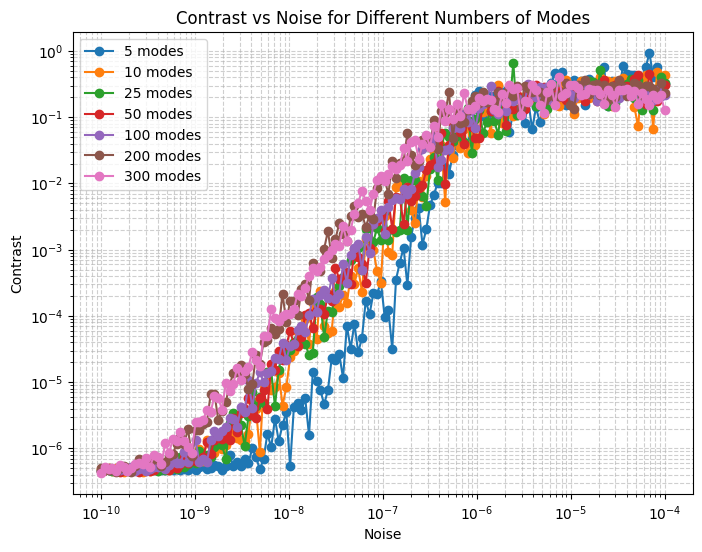

In [58]:
plt.figure(figsize=(8,6))
for modes in modes_list:
    plt.plot(noises, results[modes], label=f"{modes} modes", marker='o')
    
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Noise")
plt.ylabel("Contrast")
plt.title("Contrast vs Noise for Different Numbers of Modes")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.6)
plt.show()

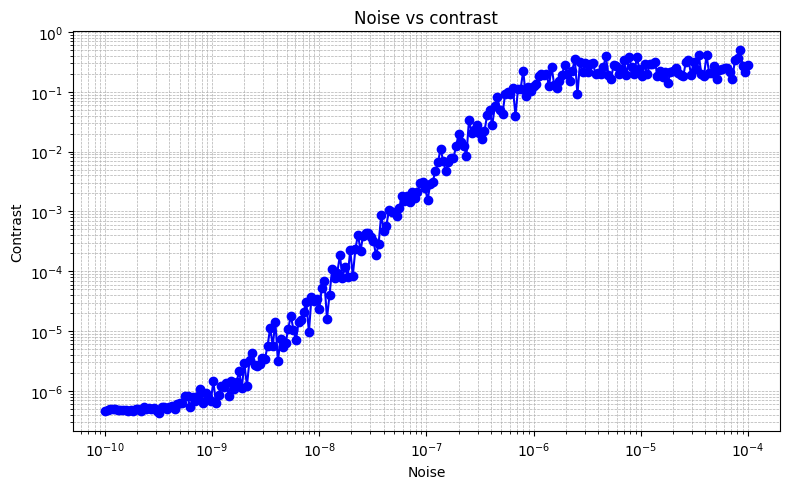

In [55]:
plt.figure(figsize=(8, 5))
plt.ylabel('Contrast')
plt.plot(noises, contrasts, marker='o', linestyle='-', color='b')
plt.xlabel('Noise')
plt.title('Noise vs contrast')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.yscale('log')
plt.xscale('log')
plt.tight_layout()
plt.show()

initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.


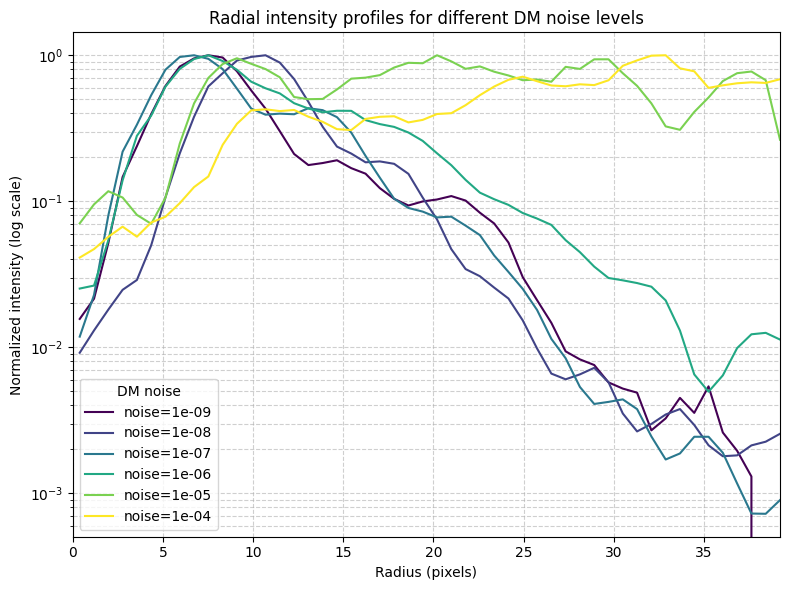

In [4]:
# generate coronagraph noisy images and plot their radial intensity profiles vs noise level

# choose environment parameters
env_kwargs = dict(
    num_modes=100,
    pixels=250,
    oversizing_factor=1,
    num_airy=7,
    coronagraph_charge=6,
    pixels_per_spacial_res=4
)

# noise levels to compare (choose a handful for clarity)
noise_levels = np.logspace(-9, -4, 6)

def radial_profile(image, center=None, nbins=200):
    y, x = np.indices(image.shape)
    if center is None:
        center = np.array(image.shape) / 2.0
    r = np.hypot(x - center[1], y - center[0]).ravel()
    vals = image.ravel()
    maxr = r.max()
    bins = np.linspace(0, maxr, nbins + 1)
    inds = np.digitize(r, bins)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    radial_mean = np.array([vals[inds == i].mean() if np.any(inds == i) else 0.0 for i in range(1, len(bins))])
    return bin_centers, radial_mean

profiles = []
radii = None

for noise in noise_levels:
    e = CoronagraphEnvironment(**env_kwargs)
    e.set_random_dm(noise=noise)
    img = e.get_camera_image(delta_t=1e3, coronagraph_enabled=True, crop=False)
    # ensure 2D numpy array
    img = np.array(img)
    r, prof = radial_profile(img, nbins=50)
    profiles.append(prof)
    if radii is None:
        radii = r

# normalize profiles for shape comparison
profiles_norm = [p / np.max(p) if np.max(p) > 0 else p for p in profiles]

# plot radial profiles
plt.figure(figsize=(8, 6))
cmap = plt.get_cmap("viridis")
for i, noise in enumerate(noise_levels):
    plt.plot(radii, profiles_norm[i], label=f"noise={noise:.0e}", color=cmap(i / max(1, len(noise_levels) - 1)))
plt.xlim(0, radii.max())
plt.yscale("log")
plt.xlabel("Radius (pixels)")
plt.ylabel("Normalized intensity (log scale)")
plt.title("Radial intensity profiles for different DM noise levels")
plt.legend(title="DM noise")
plt.grid(True, which="both", ls="--", alpha=0.6)
plt.tight_layout()
plt.show()

# Exploratory data analysis (EDA) of simulated coronagraph images

This section adds a few analyses you can run directly on images produced by `CoronagraphEnvironment`:

- Pixel intensity distributions (histograms)
- Radial contrast curves (azimuthal averages)
- Spatial power spectral density (PSD) and radial PSD
- Temporal variability maps (mean/std over time) and per-annulus variability
- SNR vs exposure time (delta_t) in a science annulus

Each cell is self-contained and can be tweaked via small config blocks at the top.

In [5]:
# Helper config and utilities for EDA
import numpy as np
import matplotlib.pyplot as plt
from environment import CoronagraphEnvironment

# Reusable environment configuration (tweak as needed)
eda_env = dict(
    num_modes=100,
    pixels=256,
    oversizing_factor=1,
    num_airy=7,
    coronagraph_charge=6,
    pixels_per_spacial_res=4,
)

# Regions of interest (in pixels from center)
roi = dict(
    inner=5,   # inner working angle for contrast/SNR plots
    outer=80,  # outer radius
)

# --- helpers ---
def radial_profile(image, center=None, nbins=200):
    img = np.asarray(image)
    y, x = np.indices(img.shape)
    if center is None:
        center = np.array(img.shape) / 2.0
    r = np.hypot(x - center[1], y - center[0]).ravel()
    vals = img.ravel()
    maxr = r.max()
    bins = np.linspace(0, maxr, nbins + 1)
    inds = np.digitize(r, bins)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    radial_mean = np.array([vals[inds == i].mean() if np.any(inds == i) else 0.0 for i in range(1, len(bins))])
    return bin_centers, radial_mean

def annulus_mask(shape, r_in, r_out, center=None):
    h, w = shape
    y, x = np.ogrid[:h, :w]
    if center is None:
        cy, cx = (h - 1) / 2.0, (w - 1) / 2.0
    else:
        cy, cx = center
    r = np.sqrt((x - cx) ** 2 + (y - cy) ** 2)
    return (r >= r_in) & (r < r_out)

def radial_psd(image, nbins=100):
    # 2D PSD via FFT magnitude squared, then azimuthal average
    img = np.asarray(image)
    img = img - img.mean()
    F = np.fft.fftshift(np.fft.fft2(img))
    P = np.abs(F) ** 2
    r, P_r = radial_profile(P, nbins=nbins)
    return r, P_r

print("EDA helpers ready. env=", eda_env)

EDA helpers ready. env= {'num_modes': 100, 'pixels': 256, 'oversizing_factor': 1, 'num_airy': 7, 'coronagraph_charge': 6, 'pixels_per_spacial_res': 4}


initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.


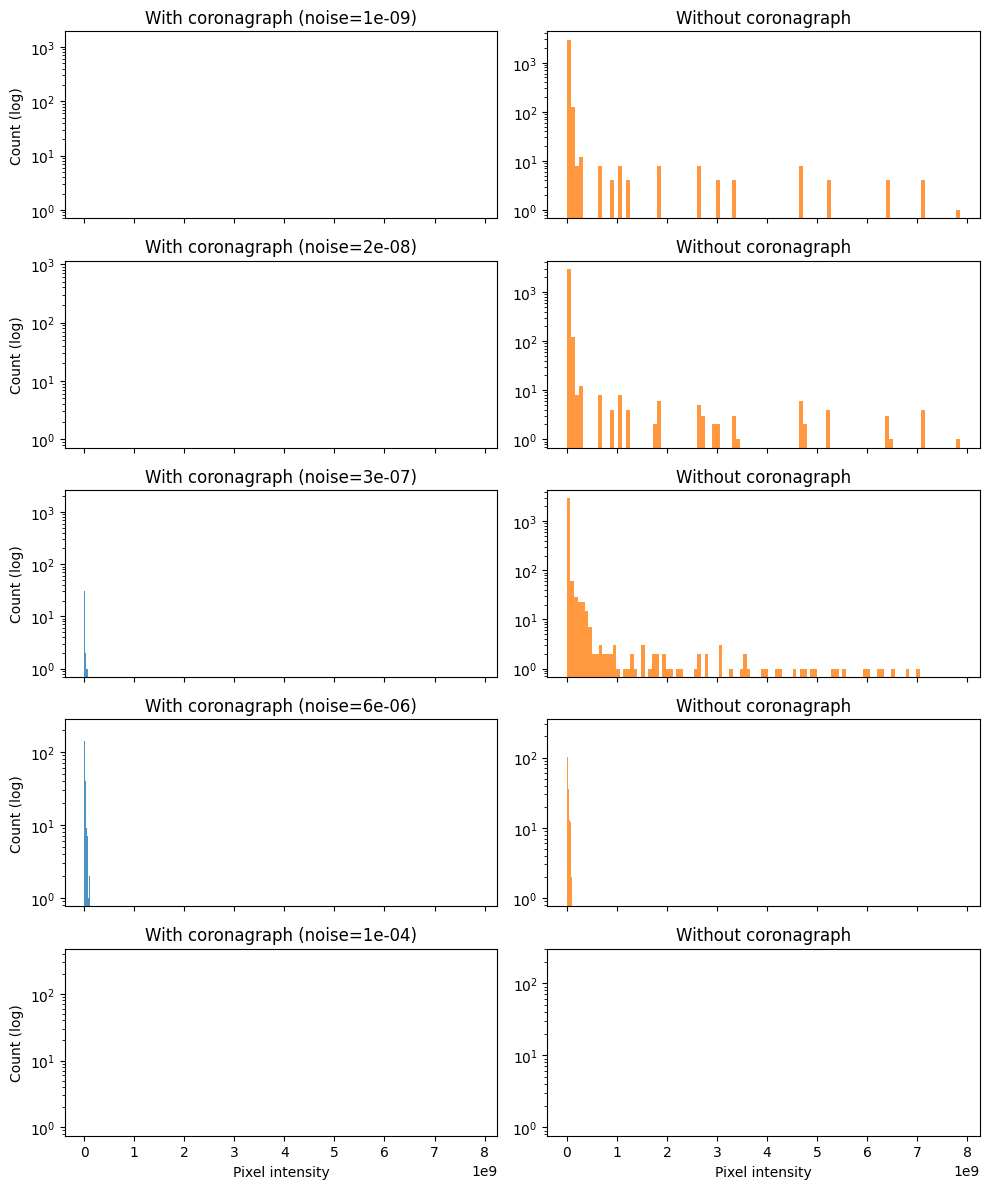

In [6]:
# Pixel intensity histograms across noise levels
noise_levels = np.logspace(-9, -4, 5)
nbins = 100

fig, axes = plt.subplots(len(noise_levels), 2, figsize=(10, 12), sharex=True)
for i, noise in enumerate(noise_levels):
    env = CoronagraphEnvironment(**eda_env)
    env.set_random_dm(noise=noise)
    img_coro = np.asarray(env.get_camera_image(delta_t=1e3, coronagraph_enabled=True, crop=False))
    img_nocoro = np.asarray(env.get_camera_image(delta_t=1e3, coronagraph_enabled=False, crop=False))

    axes[i, 0].hist(img_coro.ravel(), bins=nbins, color='tab:blue', alpha=0.8)
    axes[i, 0].set_yscale('log')
    axes[i, 0].set_title(f'With coronagraph (noise={noise:.0e})')

    axes[i, 1].hist(img_nocoro.ravel(), bins=nbins, color='tab:orange', alpha=0.8)
    axes[i, 1].set_yscale('log')
    axes[i, 1].set_title('Without coronagraph')

for ax in axes[-1, :]:
    ax.set_xlabel('Pixel intensity')
for ax in axes[:, 0]:
    ax.set_ylabel('Count (log)')
plt.tight_layout()
plt.show()

initializing coronagraph env. might take a minute.


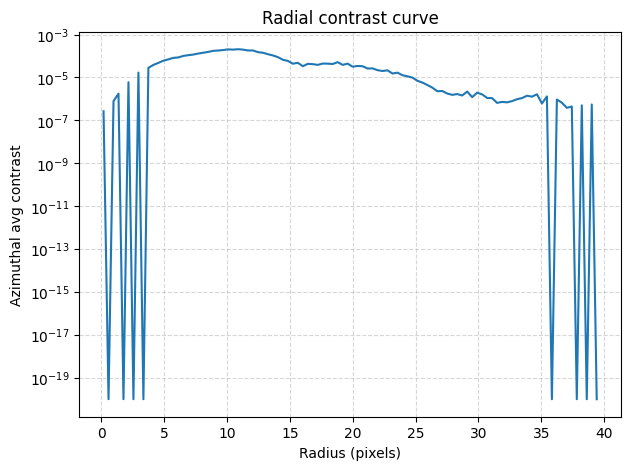

In [7]:
# Radial contrast curve (azimuthal average)
# Compute contrast vs separation by normalizing to non-coronagraphic PSF peak
noise = 1e-7
env = CoronagraphEnvironment(**eda_env)
env.set_random_dm(noise=noise)
img_coro = np.asarray(env.get_camera_image(delta_t=1e3, coronagraph_enabled=True, crop=False))
img_nocoro = np.asarray(env.get_camera_image(delta_t=1e3, coronagraph_enabled=False, crop=False))

peak = img_nocoro.max() if img_nocoro.max() > 0 else 1.0
r, prof = radial_profile(img_coro, nbins=100)
contrast_curve = prof / peak

plt.figure(figsize=(7, 5))
plt.plot(r, np.clip(contrast_curve, 1e-20, None))
plt.yscale('log')
plt.xlabel('Radius (pixels)')
plt.ylabel('Azimuthal avg contrast')
plt.title('Radial contrast curve')
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.show()

initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.


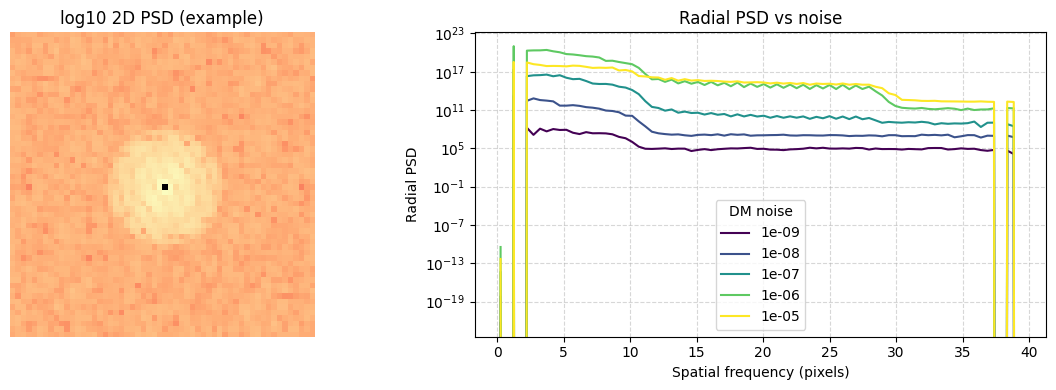

In [8]:
# Spatial power spectral density (PSD)
noise_levels = np.logspace(-9, -5, 5)
nbins = 80

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = plt.cm.viridis(np.linspace(0, 1, len(noise_levels)))

# Example 2D PSD image for one noise level
env = CoronagraphEnvironment(**eda_env)
env.set_random_dm(noise=noise_levels[0])
img = np.asarray(env.get_camera_image(delta_t=1e3, coronagraph_enabled=True, crop=False))
F = np.fft.fftshift(np.fft.fft2(img - img.mean()))
P2D = np.abs(F) ** 2
axes[0].imshow(np.log10(P2D + 1e-20), cmap='magma')
axes[0].set_title('log10 2D PSD (example)')
axes[0].axis('off')

# Radial PSD curves for different noise levels
for c, noise in zip(colors, noise_levels):
    env = CoronagraphEnvironment(**eda_env)
    env.set_random_dm(noise=noise)
    img = np.asarray(env.get_camera_image(delta_t=1e3, coronagraph_enabled=True, crop=False))
    r, p_r = radial_psd(img, nbins=nbins)
    axes[1].plot(r, p_r, color=c, label=f"{noise:.0e}")
axes[1].set_yscale('log')
axes[1].set_xlabel('Spatial frequency (pixels)')
axes[1].set_ylabel('Radial PSD')
axes[1].set_title('Radial PSD vs noise')
axes[1].grid(True, which='both', ls='--', alpha=0.5)
axes[1].legend(title='DM noise')
plt.tight_layout()
plt.show()

initializing coronagraph env. might take a minute.


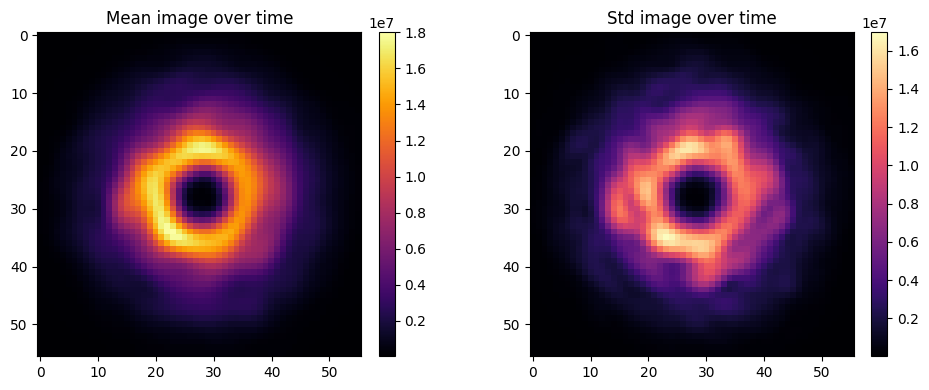

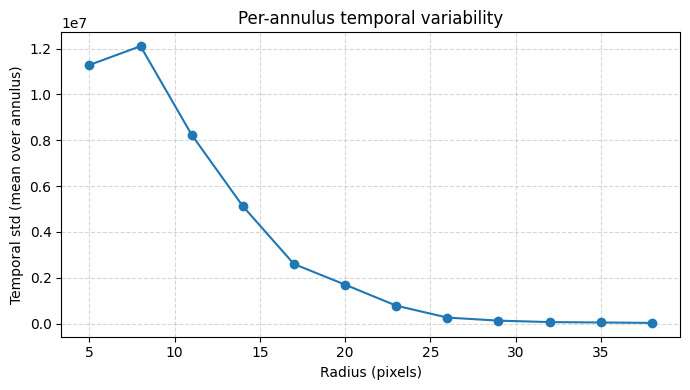

In [9]:
# Temporal variability maps and per-annulus variability
np.random.seed(0)
noise = 3e-7
T = 50  # number of frames
env = CoronagraphEnvironment(**eda_env)
imgs = []
for t in range(T):
    env.set_random_dm(noise=noise)
    imgs.append(np.asarray(env.get_camera_image(delta_t=1e3, coronagraph_enabled=True, crop=False)))
imgs = np.stack(imgs, axis=0)
mean_img = imgs.mean(axis=0)
std_img = imgs.std(axis=0)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
im0 = ax[0].imshow(mean_img, cmap='inferno')
ax[0].set_title('Mean image over time')
plt.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)
im1 = ax[1].imshow(std_img, cmap='magma')
ax[1].set_title('Std image over time')
plt.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

# Per-annulus variability
h, w = mean_img.shape
center = ( (h - 1) / 2.0, (w - 1) / 2.0 )
radii = np.arange(roi['inner'], roi['outer'], 3)
var_curve = []
for r0 in radii:
    mask = annulus_mask(mean_img.shape, r0, r0 + 3, center=center)
    var_curve.append(std_img[mask].mean() if mask.any() else np.nan)

plt.figure(figsize=(7, 4))
plt.plot(radii, var_curve, marker='o')
plt.xlabel('Radius (pixels)')
plt.ylabel('Temporal std (mean over annulus)')
plt.title('Per-annulus temporal variability')
plt.grid(True, ls='--', alpha=0.5)
plt.tight_layout()
plt.show()

initializing coronagraph env. might take a minute.


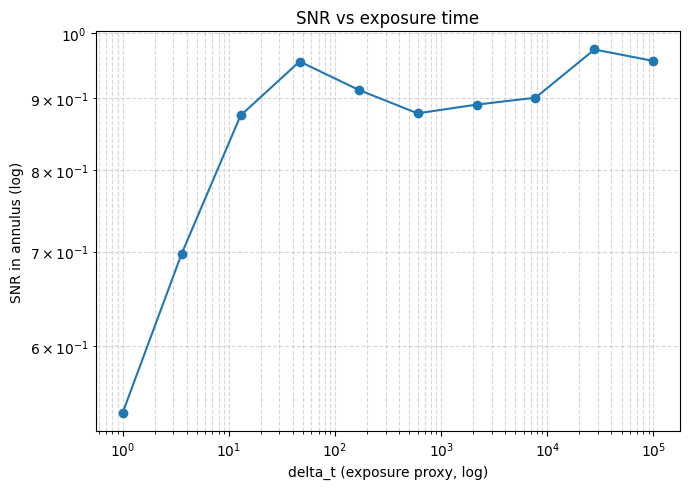

In [10]:
# SNR vs exposure time (delta_t)
# Define a fixed DM shape, vary delta_t, compute SNR in an annulus
env = CoronagraphEnvironment(**eda_env)
np.random.seed(1)
env.set_random_dm(noise=5e-7)
fixed_dm = env.deformable_mirror.actuators.copy()

annulus = (roi['inner'], roi['outer'])
delta_ts = np.logspace(0, 5, 10)  # exposure proxies
snrs = []

for dt in delta_ts:
    # ensure same DM each time
    env.set_dm(action=fixed_dm)
    img = np.asarray(env.get_camera_image(delta_t=dt, coronagraph_enabled=True, crop=False))
    # estimate signal as mean intensity in annulus, noise as std in same annulus
    mask = annulus_mask(img.shape, annulus[0], annulus[1])
    vals = img[mask]
    signal = vals.mean()
    noise = vals.std() + 1e-20
    snrs.append(signal / noise)

plt.figure(figsize=(7, 5))
plt.plot(delta_ts, snrs, marker='o')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('delta_t (exposure proxy, log)')
plt.ylabel('SNR in annulus (log)')
plt.title('SNR vs exposure time')
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.tight_layout()
plt.show()